# v0.1 Pipeline Audit — Battery Diagnostic Robustness Demonstrator

## Objective

This notebook audits the complete v0.1 diagnostic pipeline of the `battery-diagnostic-robustness-demo` project.

The goal is not to develop new functionality, but to make the existing pipeline visible and inspectable step by step:

1. Which controlled fault scenarios are simulated?
2. How do these scenarios affect cell-level and module-level signals?
3. What measured signals are produced after the sensor-layer transformation?
4. Which rule-based diagnostic criteria are activated?
5. Which faults are detected, missed, or remain ambiguous?

## Core methodological idea

An observable signal does not uniquely determine the underlying physical state.

In this project, this means:

- a voltage signal is not automatically a unique fault cause;
- a diagnostic flag is not automatically a unique root cause;
- a real fault may remain undetected if the signal magnitude, observation window, or threshold is insufficient.

## Notebook outputs

This notebook produces tables and plots for auditing:

- the v0.1 case matrix;
- single-cell truth profiles;
- 24s1p module aggregation;
- sensor-layer behavior;
- rule-level diagnostic verdicts;
- final diagnostic outcomes;
- the observability matrix.

The notebook is a visual audit layer on top of the Python modules under `src/bdr_demo/`.

In [10]:
# Cell 2 — Imports and repository path check（导入模块并检查项目路径）

from pathlib import Path
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from bdr_demo.case_matrix import V0_1_CASES, get_case
from bdr_demo.profile_generator import generate_1rc_profile, profiles_to_dataframe
from bdr_demo.module_aggregator import (
    generate_series_module_cell_profiles,
    aggregate_series_module,
    make_module_inconsistency_report,
)
from bdr_demo.sensors import apply_case_sensor_model, sensed_profiles_to_dataframe
from bdr_demo.diagnostics import compute_diagnostic_report
from bdr_demo.observability import observability_to_dataframe
from bdr_demo.pipeline import run_all_cases, run_pipeline


def find_repo_root(start: Path) -> Path:
    """Find repository root by walking upward from the notebook directory."""
    current = start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / ".git").exists():
            return candidate

    raise RuntimeError(f"Could not locate repo root from: {start}")


NOTEBOOK_START_DIR = Path.cwd().resolve()
REPO_ROOT = find_repo_root(NOTEBOOK_START_DIR)

# Critical: make all package-level relative paths resolve from repo root.
os.chdir(REPO_ROOT)

REPORT_DIR = REPO_ROOT / "reports"
PLOT_DIR = REPORT_DIR / "plots"
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
OCV_TABLE_PATH = REPO_ROOT / "data" / "ocv" / "ocv_chen2020.csv"

print("[notebook start directory]", NOTEBOOK_START_DIR)
print("[active working directory]", Path.cwd().resolve())
print("[repo root]", REPO_ROOT)
print("[reports]", REPORT_DIR)
print("[plots]", PLOT_DIR)
print("[notebooks]", NOTEBOOK_DIR)
print("[OCV table]", OCV_TABLE_PATH)
print("[case count]", len(V0_1_CASES))

assert REPO_ROOT.name == "battery-diagnostic-robustness-demo"
assert Path.cwd().resolve() == REPO_ROOT
assert REPORT_DIR.exists(), f"Missing reports directory: {REPORT_DIR}"
assert OCV_TABLE_PATH.exists(), f"Missing OCV table: {OCV_TABLE_PATH}"
assert len(V0_1_CASES) == 8

print("[OK] Repository root detected correctly.")
print("[OK] Working directory switched to repo root.")
print("[OK] Static OCV table found.")
print("[OK] Case matrix contains 8 cases.")

[notebook start directory] /Users/louislu/projects/battery-diagnostic-robustness-demo/notebooks
[active working directory] /Users/louislu/projects/battery-diagnostic-robustness-demo
[repo root] /Users/louislu/projects/battery-diagnostic-robustness-demo
[reports] /Users/louislu/projects/battery-diagnostic-robustness-demo/reports
[plots] /Users/louislu/projects/battery-diagnostic-robustness-demo/reports/plots
[notebooks] /Users/louislu/projects/battery-diagnostic-robustness-demo/notebooks
[OCV table] /Users/louislu/projects/battery-diagnostic-robustness-demo/data/ocv/ocv_chen2020.csv
[case count] 8
[OK] Repository root detected correctly.
[OK] Working directory switched to repo root.
[OK] Static OCV table found.
[OK] Case matrix contains 8 cases.


## 1. Case matrix audit

The first audit step checks which controlled fault scenarios are defined in v0.1.

The eight cases cover the following categories:

- healthy reference;
- cell-level fault;
- sensor-layer deviation;
- module-level scatter;
- combined fault.

The fault labels represent ground truth. The diagnostic pipeline must not simply reuse this information. It must derive a final verdict from generated signals, rule-level metrics, and expected fault signatures.

In [8]:
# Cell 4 — Case matrix overview（显示并检查 v0.1 八个受控故障场景）

case_df = pd.DataFrame([case.__dict__ for case in V0_1_CASES])

display_cols = [
    "case_id",
    "level",
    "fault_label",
    "capacity_factor",
    "contact_resistance_factor",
    "initial_soc_mismatch",
    "voltage_bias_mV",
    "cell_scatter_type",
    "cell_scatter_magnitude",
]

expected_case_ids = {
    "baseline",
    "capacity_fade_90",
    "contact_resistance_150",
    "initial_soc_mismatch_p05",
    "voltage_bias_p10mV",
    "module_soc_scatter",
    "module_capacity_scatter",
    "combined_fault",
}

assert len(case_df) == 8
assert set(case_df["case_id"]) == expected_case_ids

print("[OK] Case matrix contains 8 locked v0.1 cases.")
print("[OK] Case IDs match the expected v0.1 contract.")

case_df[display_cols]

[OK] Case matrix contains 8 locked v0.1 cases.
[OK] Case IDs match the expected v0.1 contract.


,case_id,level,fault_label,capacity_factor,contact_resistance_factor,initial_soc_mismatch,voltage_bias_mV,cell_scatter_type,cell_scatter_magnitude
0,baseline,cell,none,1.0,1.0,0.00,0.0,none,0.00
1,capacity_fade_90,cell,capacity_fade,0.9,1.0,0.00,0.0,none,0.00
2,contact_resistance_150,cell,contact_resistance_growth,1.0,1.5,0.00,0.0,none,0.00
3,initial_soc_mismatch_p05,cell,initial_soc_inventory_offset,1.0,1.0,0.05,0.0,none,0.00
4,voltage_bias_p10mV,cell,voltage_sensor_bias,1.0,1.0,0.00,10.0,none,0.00
5,module_soc_scatter,module,cell_imbalance,1.0,1.0,0.00,0.0,soc,0.05
6,module_capacity_scatter,module,capacity_inconsistency,1.0,1.0,0.00,0.0,capacity,0.05
7,combined_fault,module,combined,0.9,1.5,0.05,10.0,mixed,0.05


## 2. Single-cell truth profile audit

This section audits the physical truth layer before any sensor deviation or diagnostic rule is applied.

The goal is to inspect how selected cell-level perturbations change the simulated single-cell trajectory:

- `baseline`: healthy reference;
- `capacity_fade_90`: reduced effective capacity;
- `contact_resistance_150`: increased ohmic/contact-resistance surrogate;
- `initial_soc_mismatch_p05`: true initial SOC is shifted by +5 percentage points.

At this stage, all signals are physical truth-layer signals. No sensor bias and no diagnostic inference are applied yet.

In [13]:
# Cell 6 — Generate selected single-cell truth profiles（生成单体 truth-layer 曲线）

single_cell_case_ids = [
    "baseline",
    "capacity_fade_90",
    "contact_resistance_150",
    "initial_soc_mismatch_p05",
]

single_cell_profiles = {}

for case_id in single_cell_case_ids:
    case = get_case(case_id)
    rows = generate_1rc_profile(
        case,
        cell_id=1,
        initial_soc_assumed=0.80,
        discharge_current_A=1.0,
        t_end_s=600.0,
        dt_s=1.0,
    )
    df = profiles_to_dataframe(rows)
    single_cell_profiles[case_id] = df

summary_rows = []
for case_id, df in single_cell_profiles.items():
    summary_rows.append(
        {
            "case_id": case_id,
            "n_rows": len(df),
            "soc_start": df["soc_true"].iloc[0],
            "soc_end": df["soc_true"].iloc[-1],
            "soc_drop": df["soc_true"].iloc[0] - df["soc_true"].iloc[-1],
            "voltage_start_V": df["voltage_true_V"].iloc[0],
            "voltage_end_V": df["voltage_true_V"].iloc[-1],
            "voltage_drop_V": df["voltage_true_V"].iloc[0] - df["voltage_true_V"].iloc[-1],
            "r0_Ohm": df["r0_Ohm"].iloc[0],
            "capacity_Ah": df["capacity_Ah"].iloc[0],
        }
    )

single_cell_summary = pd.DataFrame(summary_rows)
single_cell_summary

# Audit checks（审计检查）
capacity_fade_capacity = single_cell_summary.loc[
    single_cell_summary["case_id"] == "capacity_fade_90",
    "capacity_Ah",
].iloc[0]

contact_r0 = single_cell_summary.loc[
    single_cell_summary["case_id"] == "contact_resistance_150",
    "r0_Ohm",
].iloc[0]

initial_soc = single_cell_summary.loc[
    single_cell_summary["case_id"] == "initial_soc_mismatch_p05",
    "soc_start",
].iloc[0]

print("[debug] capacity_fade_90 capacity_Ah =", capacity_fade_capacity)
print("[debug] contact_resistance_150 r0_Ohm =", contact_r0)
print("[debug] initial_soc_mismatch_p05 soc_start =", initial_soc)

assert np.isclose(capacity_fade_capacity, 3.15)
assert np.isclose(contact_r0, 0.075)
assert np.isclose(initial_soc, 0.85)

print("[OK] Single-cell truth profiles generated for 4 selected cases.")
print("[OK] capacity_fade_90 uses reduced capacity: 3.15 Ah.")
print("[OK] contact_resistance_150 uses increased R0: 0.075 Ohm.")
print("[OK] initial_soc_mismatch_p05 starts at true SOC = 0.85.")


[debug] capacity_fade_90 capacity_Ah = 3.15
[debug] contact_resistance_150 r0_Ohm = 0.07500000000000001
[debug] initial_soc_mismatch_p05 soc_start = 0.8500000000000001
[OK] Single-cell truth profiles generated for 4 selected cases.
[OK] capacity_fade_90 uses reduced capacity: 3.15 Ah.
[OK] contact_resistance_150 uses increased R0: 0.075 Ohm.
[OK] initial_soc_mismatch_p05 starts at true SOC = 0.85.


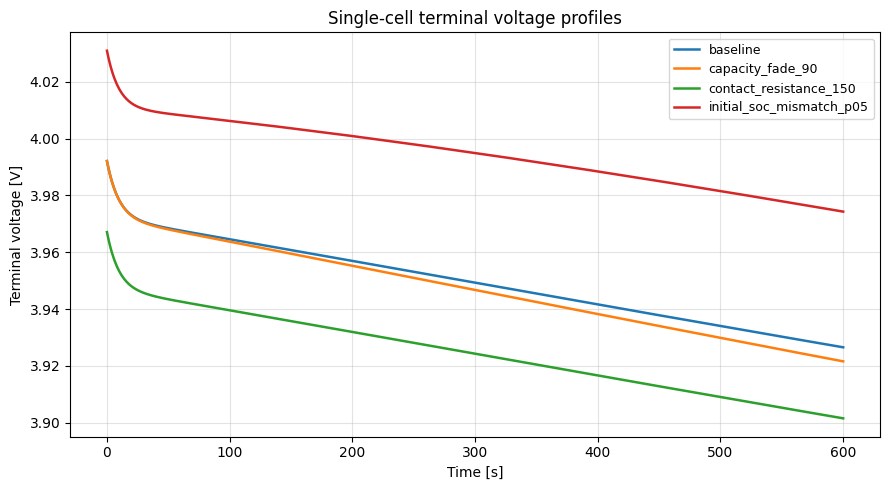

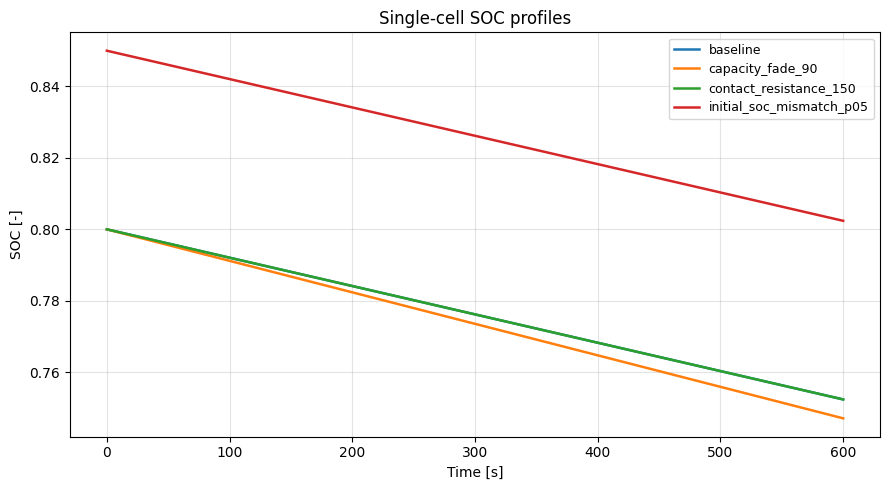

[OK] Voltage and SOC profiles plotted for selected single-cell cases.


In [14]:
# Cell 7 — Plot terminal voltage and SOC profiles（绘制端电压和 SOC 曲线）

fig, ax = plt.subplots(figsize=(9, 5))

for case_id, df in single_cell_profiles.items():
    ax.plot(df["t_s"], df["voltage_true_V"], label=case_id, linewidth=1.8)

ax.set_title("Single-cell terminal voltage profiles")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Terminal voltage [V]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))

for case_id, df in single_cell_profiles.items():
    ax.plot(df["t_s"], df["soc_true"], label=case_id, linewidth=1.8)

ax.set_title("Single-cell SOC profiles")
ax.set_xlabel("Time [s]")
ax.set_ylabel("SOC [-]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("[OK] Voltage and SOC profiles plotted for selected single-cell cases.")

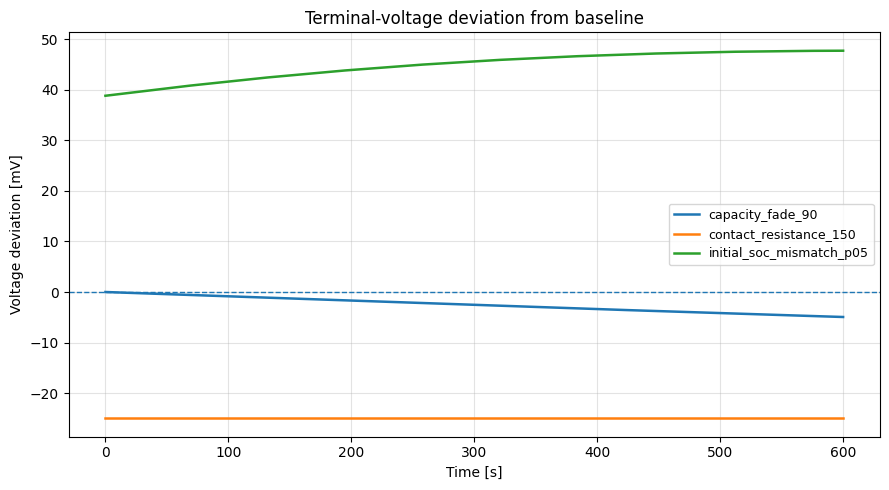

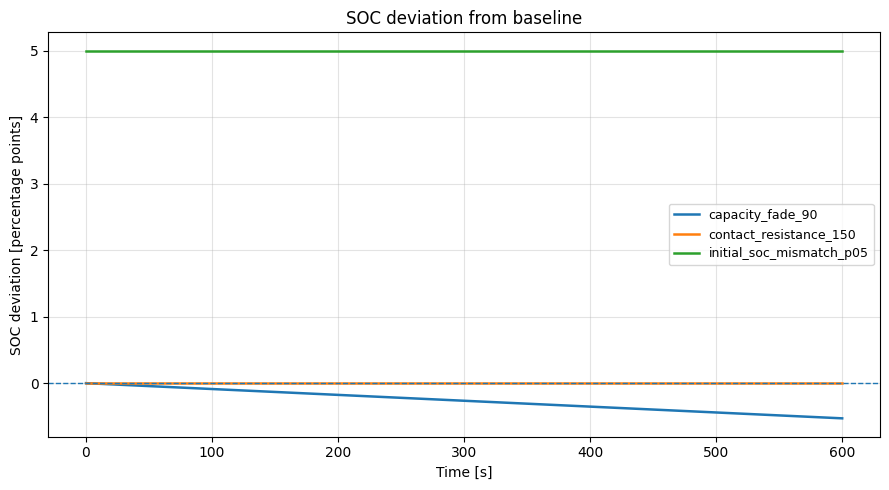

,case_id,delta_voltage_start_mV,delta_voltage_end_mV,delta_voltage_min_mV,delta_voltage_max_mV
0,capacity_fade_90,0.000000,-4.945358,-4.945358,0.000000
1,contact_resistance_150,-25.000000,-25.000000,-25.000000,-25.000000
2,initial_soc_mismatch_p05,38.834625,47.748189,38.834625,47.748189


,case_id,delta_soc_start_pct,delta_soc_end_pct,delta_soc_min_pct,delta_soc_max_pct
0,capacity_fade_90,0.0,-0.529101,-0.529101,0.0
1,contact_resistance_150,0.0,0.000000,0.000000,0.0
2,initial_soc_mismatch_p05,5.0,5.000000,5.000000,5.0


[OK] Generated voltage-deviation plot relative to baseline.
[OK] Generated SOC-deviation plot relative to baseline.
[OK] contact_resistance_150 shows the expected -25 mV initial voltage shift.
[OK] initial_soc_mismatch_p05 shows the expected +5 percentage point SOC shift.


In [15]:
# Cell 8 — Plot deviations relative to baseline（生成相对 baseline 的电压与 SOC 偏差图）

baseline_df = single_cell_profiles["baseline"].set_index("t_s")

fig, ax = plt.subplots(figsize=(9, 5))

voltage_delta_summary = []

for case_id, df in single_cell_profiles.items():
    if case_id == "baseline":
        continue

    aligned = df.set_index("t_s").join(
        baseline_df[["voltage_true_V"]].rename(
            columns={"voltage_true_V": "voltage_baseline_V"}
        ),
        how="inner",
    )

    delta_mV = 1000.0 * (
        aligned["voltage_true_V"] - aligned["voltage_baseline_V"]
    )

    ax.plot(aligned.index, delta_mV, label=case_id, linewidth=1.8)

    voltage_delta_summary.append(
        {
            "case_id": case_id,
            "delta_voltage_start_mV": delta_mV.iloc[0],
            "delta_voltage_end_mV": delta_mV.iloc[-1],
            "delta_voltage_min_mV": delta_mV.min(),
            "delta_voltage_max_mV": delta_mV.max(),
        }
    )

ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_title("Terminal-voltage deviation from baseline")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage deviation [mV]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9, 5))

soc_delta_summary = []

for case_id, df in single_cell_profiles.items():
    if case_id == "baseline":
        continue

    aligned = df.set_index("t_s").join(
        baseline_df[["soc_true"]].rename(columns={"soc_true": "soc_baseline"}),
        how="inner",
    )

    delta_soc_pct = 100.0 * (
        aligned["soc_true"] - aligned["soc_baseline"]
    )

    ax.plot(aligned.index, delta_soc_pct, label=case_id, linewidth=1.8)

    soc_delta_summary.append(
        {
            "case_id": case_id,
            "delta_soc_start_pct": delta_soc_pct.iloc[0],
            "delta_soc_end_pct": delta_soc_pct.iloc[-1],
            "delta_soc_min_pct": delta_soc_pct.min(),
            "delta_soc_max_pct": delta_soc_pct.max(),
        }
    )

ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_title("SOC deviation from baseline")
ax.set_xlabel("Time [s]")
ax.set_ylabel("SOC deviation [percentage points]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


voltage_delta_df = pd.DataFrame(voltage_delta_summary)
soc_delta_df = pd.DataFrame(soc_delta_summary)

display(voltage_delta_df)
display(soc_delta_df)

# Audit checks（审计检查）
contact_start_delta = voltage_delta_df.loc[
    voltage_delta_df["case_id"] == "contact_resistance_150",
    "delta_voltage_start_mV",
].iloc[0]

initial_soc_delta = soc_delta_df.loc[
    soc_delta_df["case_id"] == "initial_soc_mismatch_p05",
    "delta_soc_start_pct",
].iloc[0]

assert np.isclose(contact_start_delta, -25.0)
assert np.isclose(initial_soc_delta, 5.0)

print("[OK] Generated voltage-deviation plot relative to baseline.")
print("[OK] Generated SOC-deviation plot relative to baseline.")
print("[OK] contact_resistance_150 shows the expected -25 mV initial voltage shift.")
print("[OK] initial_soc_mismatch_p05 shows the expected +5 percentage point SOC shift.")

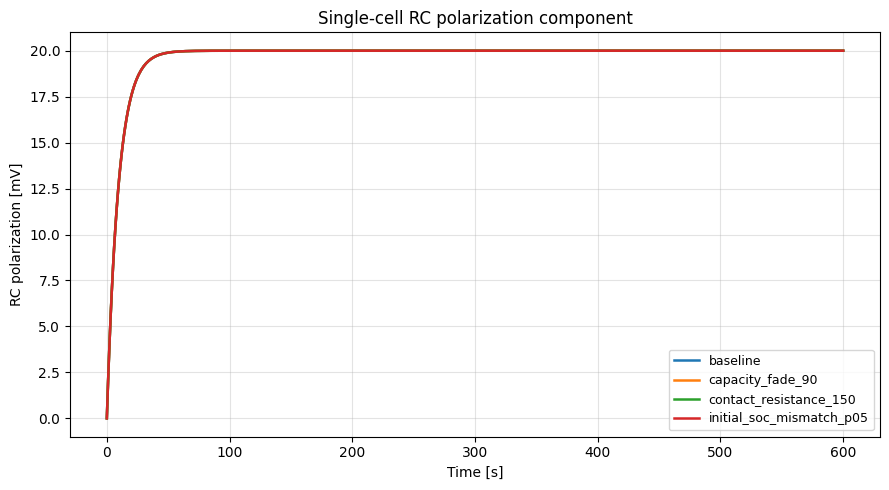

,case_id,v_rc_end_mV
0,baseline,20.0
1,capacity_fade_90,20.0
2,contact_resistance_150,20.0
3,initial_soc_mismatch_p05,20.0


[OK] Generated RC-polarization plot.
[OK] All selected cases converge to approximately 20 mV RC polarization.
[OK] This is expected because R1=0.02 Ohm and I=1 A in all selected profiles.


In [16]:
# Cell 9 — Plot RC polarization component（生成 1RC 极化电压项曲线）

fig, ax = plt.subplots(figsize=(9, 5))

for case_id, df in single_cell_profiles.items():
    ax.plot(
        df["t_s"],
        1000.0 * df["v_rc_V"],
        label=case_id,
        linewidth=1.8,
    )

ax.set_title("Single-cell RC polarization component")
ax.set_xlabel("Time [s]")
ax.set_ylabel("RC polarization [mV]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

rc_end_values = {
    case_id: 1000.0 * df["v_rc_V"].iloc[-1]
    for case_id, df in single_cell_profiles.items()
}

rc_end_df = pd.DataFrame(
    [{"case_id": k, "v_rc_end_mV": v} for k, v in rc_end_values.items()]
)

display(rc_end_df)

# Audit check（审计检查）
# In v0.1, all selected single-cell cases use the same R1 and C1.
# Under 1 A discharge, steady RC polarization approaches I*R1 = 20 mV.
assert all(np.isclose(v, 20.0) for v in rc_end_values.values())

print("[OK] Generated RC-polarization plot.")
print("[OK] All selected cases converge to approximately 20 mV RC polarization.")
print("[OK] This is expected because R1=0.02 Ohm and I=1 A in all selected profiles.")

## 3. 24s1p module aggregation audit

This section audits the module-level truth layer.

The v0.1 module topology is a pure-series 24s1p configuration. Since all cells are connected in series, the same prescribed current flows through all cells. There is no current redistribution in v0.1.

The purpose of this section is to inspect how cell-to-cell scatter propagates into module-level observable signals:

- `module_soc_scatter`: cell-to-cell initial SOC scatter;
- `module_capacity_scatter`: cell-to-cell capacity scatter;
- `combined_fault`: capacity fade, resistance growth, SOC mismatch, voltage bias, and module-level scatter combined.

The key module-level signal is the cell-voltage spread:

    delta_cell_voltage_mV = max(cell voltage) - min(cell voltage)

This signal is used by the module-imbalance diagnostic rule.

In [17]:
# Cell 11 — Generate 24s1p module profiles（生成 24s1p 模块 truth-layer 曲线）

module_case_ids = [
    "baseline",
    "module_soc_scatter",
    "module_capacity_scatter",
    "combined_fault",
]

module_profiles = {}
module_cell_profiles = {}
module_reports = {}

for case_id in module_case_ids:
    case = get_case(case_id)

    truth_rows = generate_series_module_cell_profiles(
        case,
        initial_soc_assumed=0.80,
        discharge_current_A=1.0,
        t_end_s=600.0,
        dt_s=1.0,
    )

    module_df = aggregate_series_module(truth_rows)
    module_report = make_module_inconsistency_report(truth_rows, module_df)

    module_cell_profiles[case_id] = profiles_to_dataframe(truth_rows)
    module_profiles[case_id] = module_df
    module_reports[case_id] = module_report

# Show available module-level columns for audit transparency.
print("[debug] module_df columns:")
print(module_profiles["baseline"].columns.tolist())

module_summary = pd.DataFrame(
    [
        {
            "case_id": case_id,
            "pack_voltage_min_V": report.pack_voltage_min_V,
            "pack_voltage_max_V": report.pack_voltage_max_V,
            "cell_voltage_min_anytime_V": report.cell_voltage_min_anytime_V,
            "cell_voltage_max_anytime_V": report.cell_voltage_max_anytime_V,
            "delta_cell_voltage_max_mV": report.delta_cell_voltage_max_mV,
            "weakest_cell_id": report.weakest_cell_id,
            "weakest_cell_criterion": report.weakest_cell_criterion,
            "module_risk_flag": report.module_risk_flag,
        }
        for case_id, report in module_reports.items()
    ]
)

display(module_summary)

# Audit checks（审计检查）
baseline_spread = module_summary.loc[
    module_summary["case_id"] == "baseline",
    "delta_cell_voltage_max_mV",
].iloc[0]

soc_scatter_spread = module_summary.loc[
    module_summary["case_id"] == "module_soc_scatter",
    "delta_cell_voltage_max_mV",
].iloc[0]

capacity_scatter_spread = module_summary.loc[
    module_summary["case_id"] == "module_capacity_scatter",
    "delta_cell_voltage_max_mV",
].iloc[0]

combined_spread = module_summary.loc[
    module_summary["case_id"] == "combined_fault",
    "delta_cell_voltage_max_mV",
].iloc[0]

assert np.isclose(baseline_spread, 0.0)
assert soc_scatter_spread > 50.0
assert capacity_scatter_spread < 30.0
assert combined_spread > 50.0

print("[OK] 24s1p module profiles generated for selected module-level cases.")
print("[OK] baseline has zero cell-voltage spread.")
print("[OK] module_soc_scatter exceeds the 50 mV fail threshold.")
print("[OK] module_capacity_scatter remains below the 30 mV warning threshold.")
print("[OK] combined_fault exceeds the module-spread fail threshold.")

[debug] module_df columns:
['schema_version', 'case_id', 't_s', 'current_A', 'pack_voltage_true_V', 'min_cell_voltage_V', 'max_cell_voltage_V', 'delta_cell_voltage_mV', 'n_cells']


,case_id,pack_voltage_min_V,pack_voltage_max_V,cell_voltage_min_anytime_V,cell_voltage_max_anytime_V,delta_cell_voltage_max_mV,weakest_cell_id,weakest_cell_criterion,module_risk_flag
0,baseline,94.236922,95.809889,3.926538,3.992079,0.000000,1,lowest_min_voltage,PASS
1,module_soc_scatter,94.247049,95.772301,3.880220,4.030913,94.066178,1,lowest_min_voltage,FAIL
2,module_capacity_scatter,94.235950,95.809889,3.924186,3.992079,4.481758,1,lowest_min_voltage,PASS
3,combined_fault,94.627024,96.033232,3.894005,4.021661,91.684549,1,lowest_min_voltage,FAIL


[OK] 24s1p module profiles generated for selected module-level cases.
[OK] baseline has zero cell-voltage spread.
[OK] module_soc_scatter exceeds the 50 mV fail threshold.
[OK] module_capacity_scatter remains below the 30 mV warning threshold.
[OK] combined_fault exceeds the module-spread fail threshold.


[debug] time_col = t_s
[debug] pack_voltage_col = pack_voltage_true_V
[debug] delta_cell_voltage_col = delta_cell_voltage_mV


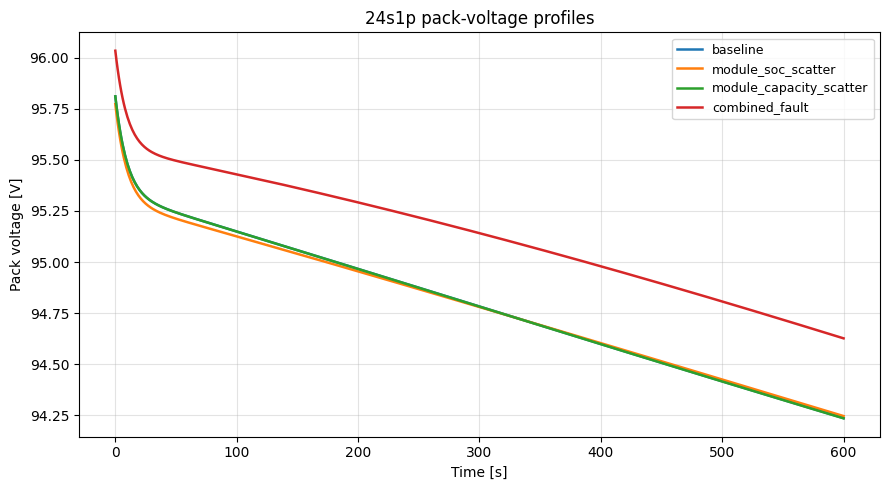

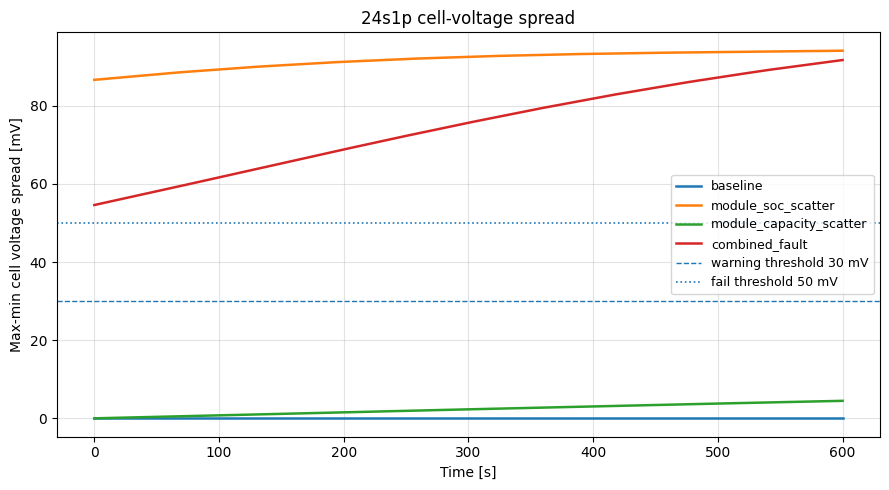

[OK] Generated pack-voltage plot.
[OK] Generated cell-voltage-spread plot.


In [18]:
# Cell 12 — Plot pack voltage and cell-voltage spread（绘制模块总电压与 cell 电压差）

# Helper: find expected module columns robustly.
def require_column(df: pd.DataFrame, candidates: list[str]) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"None of these columns found: {candidates}. Available: {df.columns.tolist()}")


sample_module_df = module_profiles["baseline"]

time_col = require_column(sample_module_df, ["t_s", "time_s"])
pack_voltage_col = require_column(
    sample_module_df,
    ["pack_voltage_true_V", "pack_voltage_V", "module_voltage_true_V", "module_voltage_V"],
)
delta_cell_voltage_col = require_column(
    sample_module_df,
    ["delta_cell_voltage_mV", "cell_voltage_spread_mV", "module_delta_voltage_mV"],
)

print("[debug] time_col =", time_col)
print("[debug] pack_voltage_col =", pack_voltage_col)
print("[debug] delta_cell_voltage_col =", delta_cell_voltage_col)

# Plot pack voltage.
fig, ax = plt.subplots(figsize=(9, 5))

for case_id, df in module_profiles.items():
    ax.plot(df[time_col], df[pack_voltage_col], label=case_id, linewidth=1.8)

ax.set_title("24s1p pack-voltage profiles")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Pack voltage [V]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Plot cell-voltage spread.
fig, ax = plt.subplots(figsize=(9, 5))

for case_id, df in module_profiles.items():
    ax.plot(df[time_col], df[delta_cell_voltage_col], label=case_id, linewidth=1.8)

ax.axhline(30.0, linestyle="--", linewidth=1.0, label="warning threshold 30 mV")
ax.axhline(50.0, linestyle=":", linewidth=1.2, label="fail threshold 50 mV")

ax.set_title("24s1p cell-voltage spread")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Max-min cell voltage spread [mV]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("[OK] Generated pack-voltage plot.")
print("[OK] Generated cell-voltage-spread plot.")

[debug] cell_min_col = min_cell_voltage_V
[debug] cell_max_col = max_cell_voltage_V


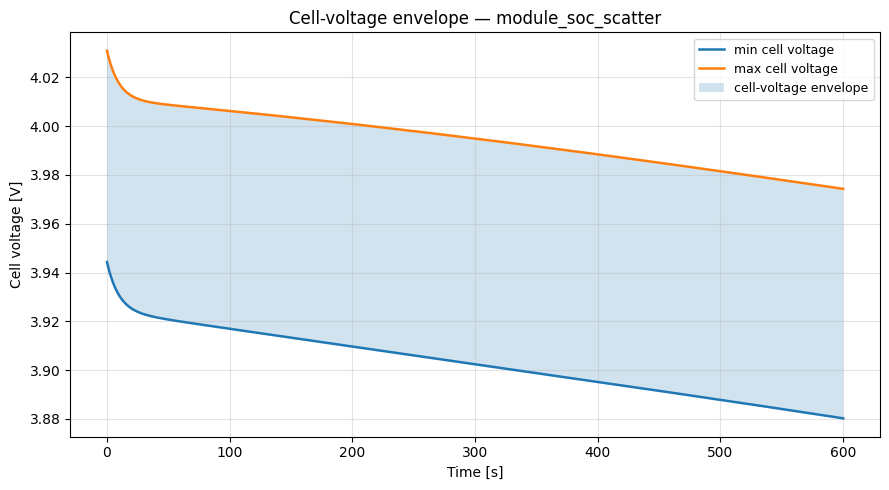

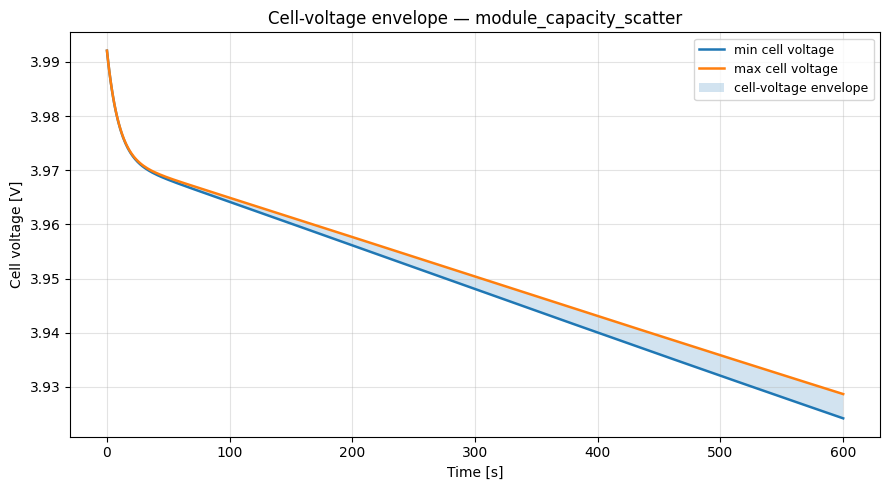

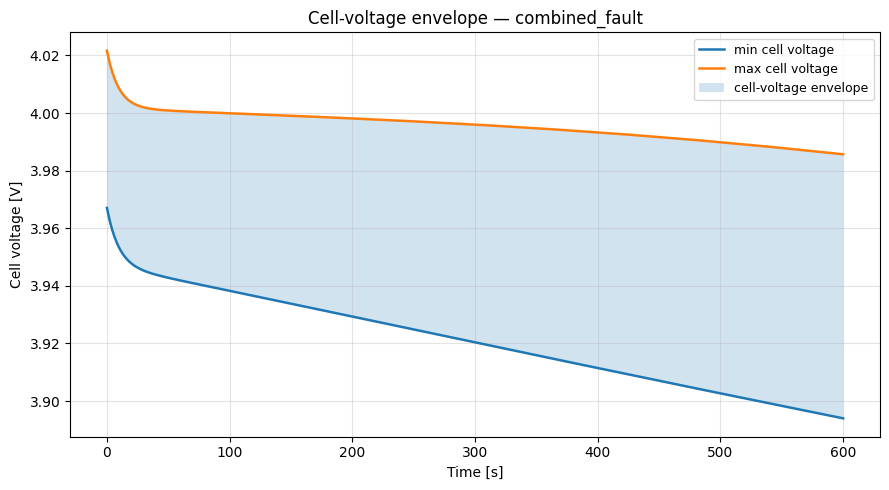

[OK] Generated min/max cell-voltage envelope plots.
[OK] Envelope width visualizes module-level signal observability.


In [19]:
# Cell 13 — Plot min/max cell-voltage envelope（绘制模块内 cell 电压包络）

# Find envelope columns.
cell_min_col = require_column(
    sample_module_df,
    ["cell_voltage_min_V", "min_cell_voltage_V", "cell_min_voltage_V"],
)
cell_max_col = require_column(
    sample_module_df,
    ["cell_voltage_max_V", "max_cell_voltage_V", "cell_max_voltage_V"],
)

print("[debug] cell_min_col =", cell_min_col)
print("[debug] cell_max_col =", cell_max_col)

for case_id in ["module_soc_scatter", "module_capacity_scatter", "combined_fault"]:
    df = module_profiles[case_id]

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(df[time_col], df[cell_min_col], label="min cell voltage", linewidth=1.8)
    ax.plot(df[time_col], df[cell_max_col], label="max cell voltage", linewidth=1.8)
    ax.fill_between(
        df[time_col],
        df[cell_min_col],
        df[cell_max_col],
        alpha=0.20,
        label="cell-voltage envelope",
    )

    ax.set_title(f"Cell-voltage envelope — {case_id}")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Cell voltage [V]")
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

print("[OK] Generated min/max cell-voltage envelope plots.")
print("[OK] Envelope width visualizes module-level signal observability.")

In [20]:
# Cell 14 — Interpret module-level diagnostic visibility（模块层诊断可见性解释表）

module_visibility_rows = []

for case_id in module_case_ids:
    report = module_reports[case_id]
    spread = report.delta_cell_voltage_max_mV

    if spread >= 50.0:
        visibility = "detected_by_module_spread_fail"
    elif spread >= 30.0:
        visibility = "weak_warning_region"
    else:
        visibility = "not_visible_under_current_threshold"

    module_visibility_rows.append(
        {
            "case_id": case_id,
            "fault_label": get_case(case_id).fault_label,
            "delta_cell_voltage_max_mV": spread,
            "module_risk_flag": report.module_risk_flag,
            "visibility_interpretation": visibility,
        }
    )

module_visibility_df = pd.DataFrame(module_visibility_rows)
display(module_visibility_df)

# Audit checks（审计检查）
module_capacity_visibility = module_visibility_df.loc[
    module_visibility_df["case_id"] == "module_capacity_scatter",
    "visibility_interpretation",
].iloc[0]

module_soc_visibility = module_visibility_df.loc[
    module_visibility_df["case_id"] == "module_soc_scatter",
    "visibility_interpretation",
].iloc[0]

assert module_capacity_visibility == "not_visible_under_current_threshold"
assert module_soc_visibility == "detected_by_module_spread_fail"

print("[OK] module_soc_scatter is visible through module voltage spread.")
print("[OK] module_capacity_scatter is not visible under the current 600 s / 1 A window.")
print("[OK] This explains why module_capacity_scatter becomes FAIL_MISSED_FAULT in v0.1.")

,case_id,fault_label,delta_cell_voltage_max_mV,module_risk_flag,visibility_interpretation
0,baseline,none,0.000000,PASS,not_visible_under_current_threshold
1,module_soc_scatter,cell_imbalance,94.066178,FAIL,detected_by_module_spread_fail
2,module_capacity_scatter,capacity_inconsistency,4.481758,PASS,not_visible_under_current_threshold
3,combined_fault,combined,91.684549,FAIL,detected_by_module_spread_fail


[OK] module_soc_scatter is visible through module voltage spread.
[OK] module_capacity_scatter is not visible under the current 600 s / 1 A window.
[OK] This explains why module_capacity_scatter becomes FAIL_MISSED_FAULT in v0.1.


## 4. Sensor-layer audit

This section audits the sensor layer.

The selected case is `voltage_bias_p10mV`, where the physical cell trajectory is healthy but the measured voltage is shifted by +10 mV.

This case is important because it is intentionally below the v0.1 voltage-residual warning threshold of 30 mV.

Expected behavior:

- true voltage remains physically normal;
- measured voltage is shifted upward by +10 mV;
- voltage residual is real but below threshold;
- all diagnostic rules remain PASS;
- final verdict is `FAIL_MISSED_FAULT`.

This demonstrates that a real sensor-layer deviation can remain invisible if the signal magnitude is below the diagnostic threshold.

In [21]:
# Cell 16 — Generate sensor-layer data for voltage_bias_p10mV（生成电压传感器偏差场景）

sensor_case_id = "voltage_bias_p10mV"
sensor_case = get_case(sensor_case_id)

# Use a 24s1p module generation path for consistency with the full pipeline.
# The cell behavior is physically healthy; only the sensor layer applies +10 mV.
sensor_truth_rows = generate_series_module_cell_profiles(
    sensor_case,
    initial_soc_assumed=0.80,
    discharge_current_A=1.0,
    t_end_s=600.0,
    dt_s=1.0,
)

sensor_module_df = aggregate_series_module(sensor_truth_rows)
sensor_sensed_rows = apply_case_sensor_model(sensor_case, sensor_truth_rows)

sensor_truth_df = profiles_to_dataframe(sensor_truth_rows)
sensor_sensed_df = sensed_profiles_to_dataframe(sensor_sensed_rows)

# Inspect one representative cell.
sensor_truth_cell1 = sensor_truth_df[sensor_truth_df["cell_id"] == 1].copy()
sensor_sensed_cell1 = sensor_sensed_df[sensor_sensed_df["cell_id"] == 1].copy()

sensor_sensed_cell1["voltage_residual_mV"] = 1000.0 * (
    sensor_sensed_cell1["voltage_measured_V"]
    - sensor_sensed_cell1["voltage_true_V"]
)

sensor_summary = pd.DataFrame(
    [
        {
            "case_id": sensor_case_id,
            "fault_label": sensor_case.fault_label,
            "voltage_bias_mV": sensor_case.voltage_bias_mV,
            "residual_min_mV": sensor_sensed_cell1["voltage_residual_mV"].min(),
            "residual_max_mV": sensor_sensed_cell1["voltage_residual_mV"].max(),
            "residual_mean_mV": sensor_sensed_cell1["voltage_residual_mV"].mean(),
        }
    ]
)

display(sensor_summary)

# Audit checks（审计检查）
assert sensor_case.voltage_bias_mV == 10.0
assert np.isclose(sensor_sensed_cell1["voltage_residual_mV"].mean(), 10.0)
assert sensor_sensed_cell1["voltage_residual_mV"].max() < 30.0

print("[OK] Sensor-layer data generated for voltage_bias_p10mV.")
print("[OK] Measured voltage is shifted by +10 mV relative to true voltage.")
print("[OK] Voltage residual remains below the 30 mV warning threshold.")

,case_id,fault_label,voltage_bias_mV,residual_min_mV,residual_max_mV,residual_mean_mV
0,voltage_bias_p10mV,voltage_sensor_bias,10.0,10.0,10.0,10.0


[OK] Sensor-layer data generated for voltage_bias_p10mV.
[OK] Measured voltage is shifted by +10 mV relative to true voltage.
[OK] Voltage residual remains below the 30 mV warning threshold.


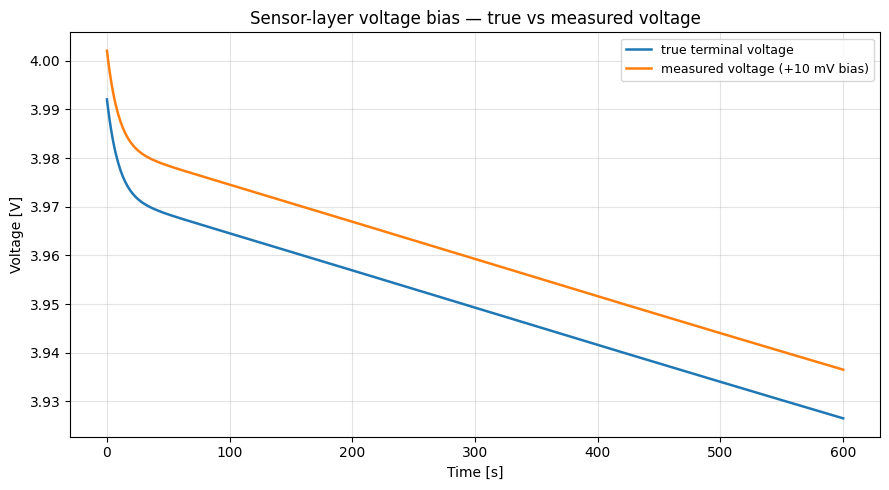

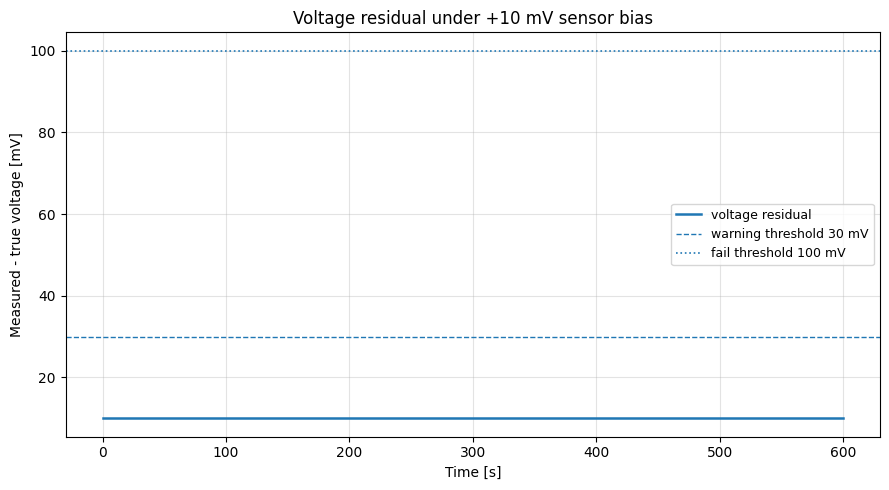

[OK] Generated true-vs-measured voltage plot.
[OK] Generated voltage-residual plot.
[OK] The residual is real but intentionally below the diagnostic threshold.


In [22]:
# Cell 17 — Plot sensor-layer true/measured voltage and residual（绘制真实电压、测量电压与残差）

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    sensor_sensed_cell1["t_s"],
    sensor_sensed_cell1["voltage_true_V"],
    label="true terminal voltage",
    linewidth=1.8,
)

ax.plot(
    sensor_sensed_cell1["t_s"],
    sensor_sensed_cell1["voltage_measured_V"],
    label="measured voltage (+10 mV bias)",
    linewidth=1.8,
)

ax.set_title("Sensor-layer voltage bias — true vs measured voltage")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    sensor_sensed_cell1["t_s"],
    sensor_sensed_cell1["voltage_residual_mV"],
    label="voltage residual",
    linewidth=1.8,
)

ax.axhline(30.0, linestyle="--", linewidth=1.0, label="warning threshold 30 mV")
ax.axhline(100.0, linestyle=":", linewidth=1.2, label="fail threshold 100 mV")

ax.set_title("Voltage residual under +10 mV sensor bias")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Measured - true voltage [mV]")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("[OK] Generated true-vs-measured voltage plot.")
print("[OK] Generated voltage-residual plot.")
print("[OK] The residual is real but intentionally below the diagnostic threshold.")

In [23]:
# Cell 18 — Compute diagnostic verdict for voltage_bias_p10mV（计算传感器偏差场景的诊断结论）

sensor_report = compute_diagnostic_report(
    sensor_case,
    sensor_sensed_rows,
    module_df=sensor_module_df,
    initial_soc_assumed=0.80,
)

sensor_report_df = pd.DataFrame([sensor_report.__dict__])

display_cols = [
    "case_id",
    "fault_label",
    "soc_error_coulomb_max",
    "soc_error_ocv_reset_max",
    "voltage_residual_max_mV",
    "capacity_consistency_error",
    "contact_R_inferred_ratio",
    "module_delta_voltage_max_mV",
    "coulomb_drift_verdict",
    "ocv_reset_verdict",
    "voltage_residual_verdict",
    "capacity_verdict",
    "contact_R_verdict",
    "module_imbalance_verdict",
    "false_positive",
    "false_negative",
    "final_verdict",
]

display(sensor_report_df[display_cols])

rule_verdict_cols = [
    "coulomb_drift_verdict",
    "ocv_reset_verdict",
    "voltage_residual_verdict",
    "capacity_verdict",
    "contact_R_verdict",
    "module_imbalance_verdict",
]

all_rule_verdicts = sensor_report_df[rule_verdict_cols].iloc[0].to_dict()

# Audit checks（审计检查）
assert all(verdict == "PASS" for verdict in all_rule_verdicts.values())
assert sensor_report.false_negative is True
assert sensor_report.final_verdict == "FAIL_MISSED_FAULT"

print("[OK] All six rule-level verdicts remain PASS.")
print("[OK] Ground-truth fault exists but no rule is triggered.")
print("[OK] Final verdict is FAIL_MISSED_FAULT.")

,case_id,fault_label,soc_error_coulomb_max,soc_error_ocv_reset_max,voltage_residual_max_mV,capacity_consistency_error,contact_R_inferred_ratio,module_delta_voltage_max_mV,coulomb_drift_verdict,ocv_reset_verdict,voltage_residual_verdict,capacity_verdict,contact_R_verdict,module_imbalance_verdict,false_positive,false_negative,final_verdict
0,voltage_bias_p10mV,voltage_sensor_bias,0.0,0.01094,10.0,0.0,1.0,0.0,PASS,PASS,PASS,PASS,PASS,PASS,False,True,FAIL_MISSED_FAULT


[OK] All six rule-level verdicts remain PASS.
[OK] Ground-truth fault exists but no rule is triggered.
[OK] Final verdict is FAIL_MISSED_FAULT.


,quantity,value_mV
0,observed residual,10.0
1,warning threshold,30.0
2,fail threshold,100.0


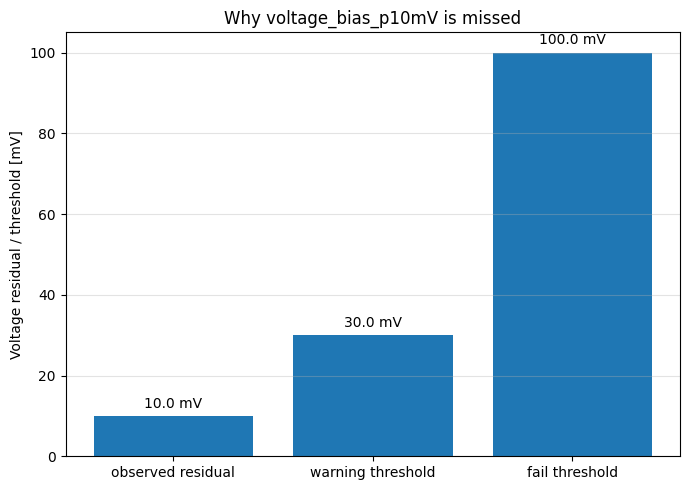

[OK] Observed residual is below the warning threshold.
[OK] This is a designed missed-fault case, not a detected ambiguous case.


In [24]:
# Cell 19 — Visual threshold explanation for missed sensor fault（用柱状图解释 missed fault）

threshold_df = pd.DataFrame(
    [
        {
            "quantity": "observed residual",
            "value_mV": sensor_report.voltage_residual_max_mV,
        },
        {
            "quantity": "warning threshold",
            "value_mV": 30.0,
        },
        {
            "quantity": "fail threshold",
            "value_mV": 100.0,
        },
    ]
)

display(threshold_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(threshold_df["quantity"], threshold_df["value_mV"])
ax.set_title("Why voltage_bias_p10mV is missed")
ax.set_ylabel("Voltage residual / threshold [mV]")
ax.grid(axis="y", alpha=0.35)

for idx, value in enumerate(threshold_df["value_mV"]):
    ax.text(idx, value + 2.0, f"{value:.1f} mV", ha="center")

plt.tight_layout()
plt.show()

assert sensor_report.voltage_residual_max_mV < 30.0

print("[OK] Observed residual is below the warning threshold.")
print("[OK] This is a designed missed-fault case, not a detected ambiguous case.")

## 5. Full diagnostic report audit

This section audits the full v0.1 diagnostic report across all eight cases.

The goal is to inspect:

- which rule-level diagnostics are activated;
- which cases are detected;
- which cases are missed;
- whether the final verdict semantics match the v0.1 contract.

The key distinction is:

- `PASS_DETECTED`: a fault exists and at least one expected rule is triggered;
- `FAIL_MISSED_FAULT`: a fault exists but no rule reports WARNING or FAIL;
- `FAIL_AMBIGUOUS_SIGNATURE`: a rule is triggered, but the active evidence is inconsistent with the injected fault label.

In [25]:
# Cell 21 — Load and verify full diagnostic report（读取并检查完整诊断报告）

diagnostic_report_path = REPORT_DIR / "diagnostic_robustness_report.csv"
module_report_path = REPORT_DIR / "module_inconsistency_report.csv"

assert diagnostic_report_path.exists(), f"Missing diagnostic report: {diagnostic_report_path}"
assert module_report_path.exists(), f"Missing module report: {module_report_path}"

diagnostic_df = pd.read_csv(diagnostic_report_path)
module_report_df = pd.read_csv(module_report_path)

display_cols = [
    "case_id",
    "fault_label",
    "coulomb_drift_verdict",
    "ocv_reset_verdict",
    "voltage_residual_verdict",
    "capacity_verdict",
    "contact_R_verdict",
    "module_imbalance_verdict",
    "false_positive",
    "false_negative",
    "final_verdict",
]

display(diagnostic_df[display_cols])

expected_final_verdicts = {
    "baseline": "PASS_HEALTHY",
    "capacity_fade_90": "PASS_DETECTED",
    "contact_resistance_150": "PASS_DETECTED",
    "initial_soc_mismatch_p05": "PASS_DETECTED",
    "voltage_bias_p10mV": "FAIL_MISSED_FAULT",
    "module_soc_scatter": "PASS_DETECTED",
    "module_capacity_scatter": "FAIL_MISSED_FAULT",
    "combined_fault": "PASS_DETECTED",
}

actual_final_verdicts = dict(
    zip(diagnostic_df["case_id"], diagnostic_df["final_verdict"])
)

assert actual_final_verdicts == expected_final_verdicts

print("[OK] Diagnostic report loaded from reports/diagnostic_robustness_report.csv.")
print("[OK] All 8 final verdicts match the v0.1 contract.")
print("[OK] Missed-fault cases are correctly classified as FAIL_MISSED_FAULT.")

,case_id,fault_label,coulomb_drift_verdict,ocv_reset_verdict,voltage_residual_verdict,capacity_verdict,contact_R_verdict,module_imbalance_verdict,false_positive,false_negative,final_verdict
0,baseline,none,PASS,PASS,PASS,PASS,PASS,PASS,False,False,PASS_HEALTHY
1,capacity_fade_90,capacity_fade,PASS,PASS,PASS,FAIL,PASS,PASS,False,False,PASS_DETECTED
2,contact_resistance_150,contact_resistance_growth,PASS,PASS,PASS,PASS,FAIL,PASS,False,False,PASS_DETECTED
3,initial_soc_mismatch_p05,initial_soc_inventory_offset,FAIL,PASS,PASS,PASS,PASS,PASS,False,False,PASS_DETECTED
4,voltage_bias_p10mV,voltage_sensor_bias,PASS,PASS,PASS,PASS,PASS,PASS,False,True,FAIL_MISSED_FAULT
5,module_soc_scatter,cell_imbalance,FAIL,PASS,PASS,PASS,PASS,FAIL,False,False,PASS_DETECTED
6,module_capacity_scatter,capacity_inconsistency,PASS,PASS,PASS,PASS,PASS,PASS,False,True,FAIL_MISSED_FAULT
7,combined_fault,combined,FAIL,WARNING,PASS,FAIL,FAIL,FAIL,False,False,PASS_DETECTED


[OK] Diagnostic report loaded from reports/diagnostic_robustness_report.csv.
[OK] All 8 final verdicts match the v0.1 contract.
[OK] Missed-fault cases are correctly classified as FAIL_MISSED_FAULT.


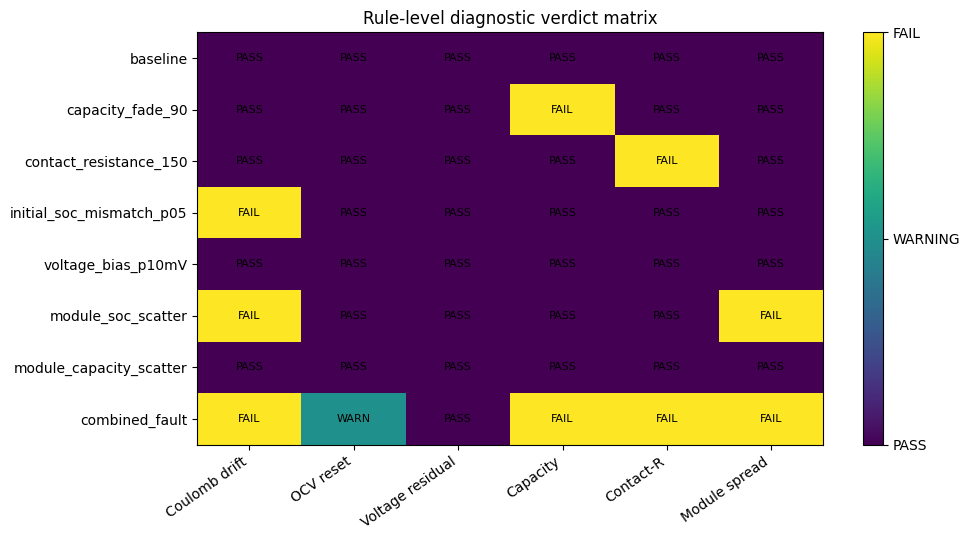

[OK] Generated rule-level verdict matrix.
[OK] PASS/WARNING/FAIL evidence is visible for all 8 cases and 6 rules.


In [26]:
# Cell 22 — Plot rule-level verdict matrix（绘制六条诊断规则的 verdict 矩阵）

rule_cols = [
    "coulomb_drift_verdict",
    "ocv_reset_verdict",
    "voltage_residual_verdict",
    "capacity_verdict",
    "contact_R_verdict",
    "module_imbalance_verdict",
]

rule_labels = [
    "Coulomb drift",
    "OCV reset",
    "Voltage residual",
    "Capacity",
    "Contact-R",
    "Module spread",
]

verdict_mapping = {
    "PASS": 0,
    "WARNING": 1,
    "FAIL": 2,
}

verdict_matrix = (
    diagnostic_df[rule_cols]
    .apply(lambda col: col.map(verdict_mapping))
    .to_numpy(dtype=float)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

image = ax.imshow(verdict_matrix, aspect="auto", vmin=0, vmax=2)

ax.set_title("Rule-level diagnostic verdict matrix")
ax.set_yticks(np.arange(len(diagnostic_df)))
ax.set_yticklabels(diagnostic_df["case_id"])
ax.set_xticks(np.arange(len(rule_labels)))
ax.set_xticklabels(rule_labels, rotation=35, ha="right")

cbar = fig.colorbar(image, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["PASS", "WARNING", "FAIL"])

# Add text annotations for audit readability.
reverse_mapping = {0: "PASS", 1: "WARN", 2: "FAIL"}

for i in range(verdict_matrix.shape[0]):
    for j in range(verdict_matrix.shape[1]):
        value = int(verdict_matrix[i, j])
        ax.text(
            j,
            i,
            reverse_mapping[value],
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

print("[OK] Generated rule-level verdict matrix.")
print("[OK] PASS/WARNING/FAIL evidence is visible for all 8 cases and 6 rules.")

,n_cases
final_verdict,
PASS_HEALTHY,1
PASS_DETECTED,5
WARNING_BOUNDARY,0
FAIL_MISSED_FAULT,2
FAIL_FALSE_ALARM,0
FAIL_AMBIGUOUS_SIGNATURE,0


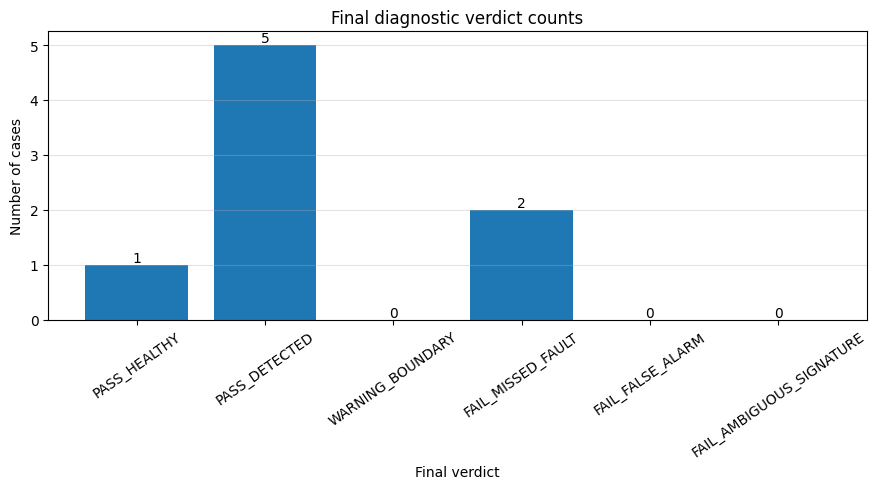

,case_id,fault_label,voltage_residual_max_mV,module_delta_voltage_max_mV,false_negative,final_verdict
4,voltage_bias_p10mV,voltage_sensor_bias,10.0,0.000000,True,FAIL_MISSED_FAULT
6,module_capacity_scatter,capacity_inconsistency,0.0,4.481758,True,FAIL_MISSED_FAULT


[OK] Generated final-verdict count plot.
[OK] voltage_bias_p10mV is correctly classified as a missed sensor-layer fault.
[OK] module_capacity_scatter is correctly classified as a missed module-level fault.
[OK] Both missed-fault cases are false negatives by design.


In [27]:
# Cell 23 — Plot final verdict counts and inspect missed faults（绘制最终 verdict 分布并审计漏检案例）

final_counts = (
    diagnostic_df["final_verdict"]
    .value_counts()
    .reindex(
        [
            "PASS_HEALTHY",
            "PASS_DETECTED",
            "WARNING_BOUNDARY",
            "FAIL_MISSED_FAULT",
            "FAIL_FALSE_ALARM",
            "FAIL_AMBIGUOUS_SIGNATURE",
        ],
        fill_value=0,
    )
)

display(final_counts.to_frame(name="n_cases"))

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(final_counts.index, final_counts.values)
ax.set_title("Final diagnostic verdict counts")
ax.set_xlabel("Final verdict")
ax.set_ylabel("Number of cases")
ax.grid(axis="y", alpha=0.35)
ax.tick_params(axis="x", rotation=35)

for idx, value in enumerate(final_counts.values):
    ax.text(idx, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()

missed_fault_df = diagnostic_df[
    diagnostic_df["final_verdict"] == "FAIL_MISSED_FAULT"
].copy()

display(
    missed_fault_df[
        [
            "case_id",
            "fault_label",
            "voltage_residual_max_mV",
            "module_delta_voltage_max_mV",
            "false_negative",
            "final_verdict",
        ]
    ]
)

expected_missed = {"voltage_bias_p10mV", "module_capacity_scatter"}
actual_missed = set(missed_fault_df["case_id"])

assert actual_missed == expected_missed
assert missed_fault_df["false_negative"].all()

print("[OK] Generated final-verdict count plot.")
print("[OK] voltage_bias_p10mV is correctly classified as a missed sensor-layer fault.")
print("[OK] module_capacity_scatter is correctly classified as a missed module-level fault.")
print("[OK] Both missed-fault cases are false negatives by design.")

## 6. Observability matrix audit

The observability matrix documents which signal channels are expected to carry evidence for each fault label.

This section checks the manually curated fault-to-signature mapping and links it to the observed diagnostic outcomes.

The matrix is not generated from the diagnostic rules. It is a design-layer artifact used to explain which fault classes are expected to be visible, weakly visible, or ambiguous under the v0.1 signal set.

In [28]:
# Cell 25 — Load and inspect observability matrix（读取并审计可观测性矩阵）

observability_df = observability_to_dataframe()

observability_display_cols = [
    "fault_label",
    "voltage_signature",
    "soc_signature",
    "soh_signature",
    "module_spread_signature",
    "ambiguity_level",
    "notes",
]

display(observability_df[observability_display_cols])

assert len(observability_df) == 8
assert set(observability_df["fault_label"]) == set(diagnostic_df["fault_label"])
assert set(observability_df["ambiguity_level"]).issubset({"low", "medium", "high"})

print("[OK] Observability matrix contains 8 fault-label rows.")
print("[OK] Fault labels match the diagnostic report.")
print("[OK] Ambiguity levels are valid.")

,fault_label,voltage_signature,soc_signature,soh_signature,module_spread_signature,ambiguity_level,notes
0,none,reference voltage trajectory,reference SOC trajectory,reference capacity and resistance,no intentional cell-to-cell spread,low,Healthy reference case. Any diagnostic flag in...
1,capacity_fade,terminal voltage may decline faster during dis...,Coulomb-counting estimate based on nominal cap...,effective capacity below nominal capacity,none for uniform capacity fade; possible sprea...,medium,Can overlap with initial SOC mismatch in SOC-e...
2,contact_resistance_growth,under-load terminal voltage is shifted lower a...,SOC trajectory remains close to baseline if ca...,contact-resistance proxy ratio exceeds baseline,none for uniform resistance growth; spread wou...,medium,Can resemble low SOC or voltage depression in ...
3,initial_soc_inventory_offset,initial voltage is shifted because true initia...,Coulomb-counting estimate starts from the assu...,capacity and resistance remain nominal,may create cell-voltage spread if mismatch is ...,medium,Can be confused with capacity fade if only SOC...
4,voltage_sensor_bias,measured voltage is shifted relative to true t...,OCV-derived SOC may shift if measured voltage ...,capacity and resistance remain physically unch...,none if the same voltage bias is applied unifo...,high,The v0.1 +10 mV bias is intentionally below th...
5,cell_imbalance,individual cell voltages separate even when pa...,cell-level SOC values differ across the series...,capacity and resistance may remain nominal,max-min cell voltage spread increases,medium,Main evidence is module-level voltage spread. ...
6,capacity_inconsistency,cell voltages diverge progressively because ce...,SOC trajectories diverge due to different effe...,cell-level effective capacities differ,cell-voltage spread increases over time,medium,Can resemble SOC imbalance in voltage-spread m...
7,combined,"mixed voltage signatures from capacity fade, c...",SOC drift and cell-to-cell SOC spread may coexist,capacity loss and resistance growth may coexist,cell-voltage spread likely increases,high,Combined case is expected to be multi-causal. ...


[OK] Observability matrix contains 8 fault-label rows.
[OK] Fault labels match the diagnostic report.
[OK] Ambiguity levels are valid.


,case_id,fault_label,final_verdict,false_negative,ambiguity_level,notes
0,baseline,none,PASS_HEALTHY,False,low,Healthy reference case. Any diagnostic flag in...
1,capacity_fade_90,capacity_fade,PASS_DETECTED,False,medium,Can overlap with initial SOC mismatch in SOC-e...
2,contact_resistance_150,contact_resistance_growth,PASS_DETECTED,False,medium,Can resemble low SOC or voltage depression in ...
3,initial_soc_mismatch_p05,initial_soc_inventory_offset,PASS_DETECTED,False,medium,Can be confused with capacity fade if only SOC...
4,voltage_bias_p10mV,voltage_sensor_bias,FAIL_MISSED_FAULT,True,high,The v0.1 +10 mV bias is intentionally below th...
5,module_soc_scatter,cell_imbalance,PASS_DETECTED,False,medium,Main evidence is module-level voltage spread. ...
6,module_capacity_scatter,capacity_inconsistency,FAIL_MISSED_FAULT,True,medium,Can resemble SOC imbalance in voltage-spread m...
7,combined_fault,combined,PASS_DETECTED,False,high,Combined case is expected to be multi-causal. ...


final_verdict,FAIL_MISSED_FAULT,PASS_DETECTED,PASS_HEALTHY
ambiguity_level,,,
high,1,1,0
low,0,0,1
medium,1,4,0


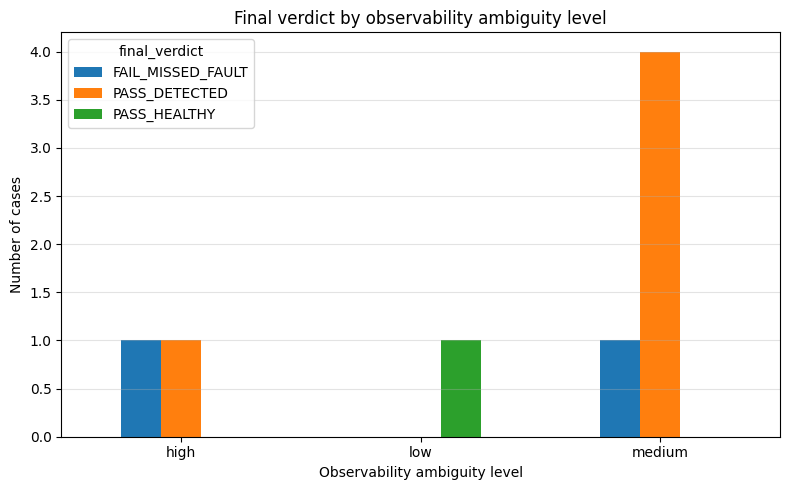

[OK] Diagnostic outcomes joined with observability ambiguity levels.
[OK] Observability matrix explains why some real faults may remain missed.


In [29]:
# Cell 26 — Join final verdicts with observability levels（关联最终诊断结果与可观测性等级）

diagnostic_observability_df = diagnostic_df[
    ["case_id", "fault_label", "final_verdict", "false_negative"]
].merge(
    observability_df[["fault_label", "ambiguity_level", "notes"]],
    on="fault_label",
    how="left",
)

display(diagnostic_observability_df)

fig, ax = plt.subplots(figsize=(8, 5))

pivot = pd.crosstab(
    diagnostic_observability_df["ambiguity_level"],
    diagnostic_observability_df["final_verdict"],
)

display(pivot)

pivot.plot(kind="bar", ax=ax)

ax.set_title("Final verdict by observability ambiguity level")
ax.set_xlabel("Observability ambiguity level")
ax.set_ylabel("Number of cases")
ax.grid(axis="y", alpha=0.35)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

assert not diagnostic_observability_df["ambiguity_level"].isna().any()

print("[OK] Diagnostic outcomes joined with observability ambiguity levels.")
print("[OK] Observability matrix explains why some real faults may remain missed.")

## 7. Notebook closure

This notebook audited the complete v0.1 diagnostic robustness pipeline.

The audit showed that the pipeline separates four layers:

1. physical truth;
2. measured signal;
3. rule-level diagnostic evidence;
4. final diagnostic verdict.

The single-cell audit confirmed that controlled parameter perturbations produce physically interpretable signal changes:

- capacity reduction accelerates SOC decrease;
- contact-resistance growth shifts terminal voltage downward;
- initial SOC mismatch shifts the entire SOC trajectory.

The module-level audit showed that cell-to-cell scatter is not uniformly observable. Initial SOC scatter produced a large cell-voltage spread and was detected by the module-spread rule. In contrast, capacity scatter remained below the module-spread threshold within the current 600 s / 1 A observation window and was therefore missed.

The sensor-layer audit showed that a real +10 mV voltage bias is present in the measured signal, but remains below the 30 mV warning threshold. The diagnostic pipeline therefore correctly classifies this case as `FAIL_MISSED_FAULT`, not as an ambiguous detected fault.

The full diagnostic report confirmed the v0.1 verdict structure:

- 1 healthy case: `PASS_HEALTHY`;
- 5 detected fault cases: `PASS_DETECTED`;
- 2 missed fault cases: `FAIL_MISSED_FAULT`;
- 0 false alarms;
- 0 ambiguous detected signatures.

The central methodological conclusion is:

A real fault may exist without being visible to the current diagnostic rule set. Diagnostic robustness therefore depends on the interaction between signal channel, threshold, observation window, and fault-to-rule mapping.

This notebook provides the visual audit layer for the v0.1 demonstrator and complements the executable pipeline under `src/bdr_demo/`.